In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.geometry.point import Point

p1 = Point(10, 20)
p2 = Point(13, 24)

print(p1)
print(p2)

print(p1.distance_to(p2))

p1.translate(5, 5)

print(p1)

print(p1.to_tuple())

Point(x=10.0, y=20.0)
Point(x=13.0, y=24.0)
5.0
Point(x=15.0, y=25.0)
(15.0, 25.0)


In [3]:
from src.geometry.line import Line

line = Line(
    Point(10, 5),
    Point(20, 25),
)

print(line)

print("Length:", line.length())

print("Midpoint:", line.midpoint())

print("Vector:", line.vector())

line.translate(10, -5)

print(line)

Line(start=Point(x=10.0, y=5.0), end=Point(x=20.0, y=25.0))
Length: 22.360679774997898
Midpoint: Point(x=15.0, y=15.0)
Vector: (10.0, 20.0)
Line(start=Point(x=20.0, y=0.0), end=Point(x=30.0, y=20.0))


In [4]:
from src.geometry.point import Point
from src.geometry.polygon import Polygon

polygon = Polygon(
    [
        Point(0,0),
        Point(4,0),
        Point(4,3),
        Point(0,3),
        Point(0,0)
    ]
)

print(polygon)

print(len(polygon))

print(polygon.vertices)

Polygon(vertices=4)
4
(Point(x=0.0, y=0.0), Point(x=4.0, y=0.0), Point(x=4.0, y=3.0), Point(x=0.0, y=3.0))


In [5]:
for edge in polygon.edges():
    print(edge)

Line(start=Point(x=0.0, y=0.0), end=Point(x=4.0, y=0.0))
Line(start=Point(x=4.0, y=0.0), end=Point(x=4.0, y=3.0))
Line(start=Point(x=4.0, y=3.0), end=Point(x=0.0, y=3.0))
Line(start=Point(x=0.0, y=3.0), end=Point(x=0.0, y=0.0))


In [6]:
polygon = Polygon(
    [
        Point(2, 5),
        Point(7, 4),
        Point(6, 9),
        Point(1, 8),
    ]
)

print(polygon.bounding_box())

BoundingBox(min_x=1.0, min_y=4.0, max_x=7.0, max_y=9.0)


In [7]:
from src.geometry.algorithms.distance import (distance_point_to_segment,)
from src.geometry.line import Line
from src.geometry.point import Point

line = Line(
    Point(0, 0),
    Point(10, 0),
)

points = [
    Point(5, 5),
    Point(-2, 3),
    Point(12, 4),
]

for point in points:

    print(
        point,
        distance_point_to_segment(
            point,
            line,
        ),
    )

Point(x=5.0, y=5.0) 5.0
Point(x=-2.0, y=3.0) 3.605551275463989
Point(x=12.0, y=4.0) 4.47213595499958


In [8]:
from src.geometry.algorithms.ray_casting import ray_intersects_segment
from src.geometry.line import Line
from src.geometry.point import Point

segment = Line(
    Point(5, 0),
    Point(5, 10),
)

points = [
    Point(2, 5),
    Point(7, 5),
    Point(2, 11),
]

for point in points:
    print(point, ray_intersects_segment(point, segment))

Point(x=2.0, y=5.0) True
Point(x=7.0, y=5.0) False
Point(x=2.0, y=11.0) False


In [9]:
from src.config import RAW_DATA_DIR
from src.io.geojson_loader import GeoJsonLoader

loader = GeoJsonLoader(
    RAW_DATA_DIR / "iran_city.json"
)

gorgan = loader.load_city("گرگان")

print(gorgan)

Polygon(vertices=326)


In [10]:
from src.geometry.algorithms.perpendicular import distance_point_to_line
from src.geometry.line import Line
from src.geometry.point import Point

line = Line(Point(0, 0), Point(10, 0))

point = Point(4, 3)

print(distance_point_to_line(point, line))

3.0


In [11]:
from src.config import RAW_DATA_DIR
from src.io.geojson_loader import GeoJsonLoader

loader = GeoJsonLoader(RAW_DATA_DIR / "iran_city.json")

gorgan = loader.load_city("گرگان")

print(len(gorgan))

simplified = gorgan.simplify(0.001)

print(len(simplified))

326
85


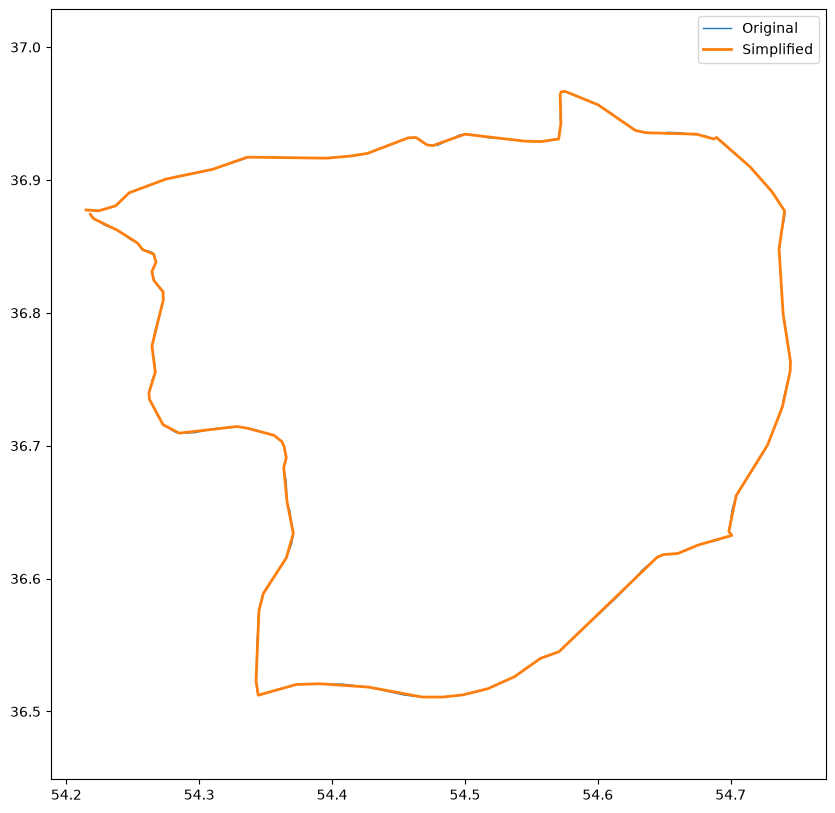

In [12]:
import matplotlib.pyplot as plt

original_x = [p.x for p in gorgan]
original_y = [p.y for p in gorgan]

simplified_x = [p.x for p in simplified]
simplified_y = [p.y for p in simplified]

plt.figure(figsize=(10, 10))

plt.plot(original_x, original_y, label="Original", linewidth=1)

plt.plot(
    simplified_x,
    simplified_y,
    linewidth=2,
    label="Simplified"
)

plt.legend()

plt.axis("equal")

plt.show()

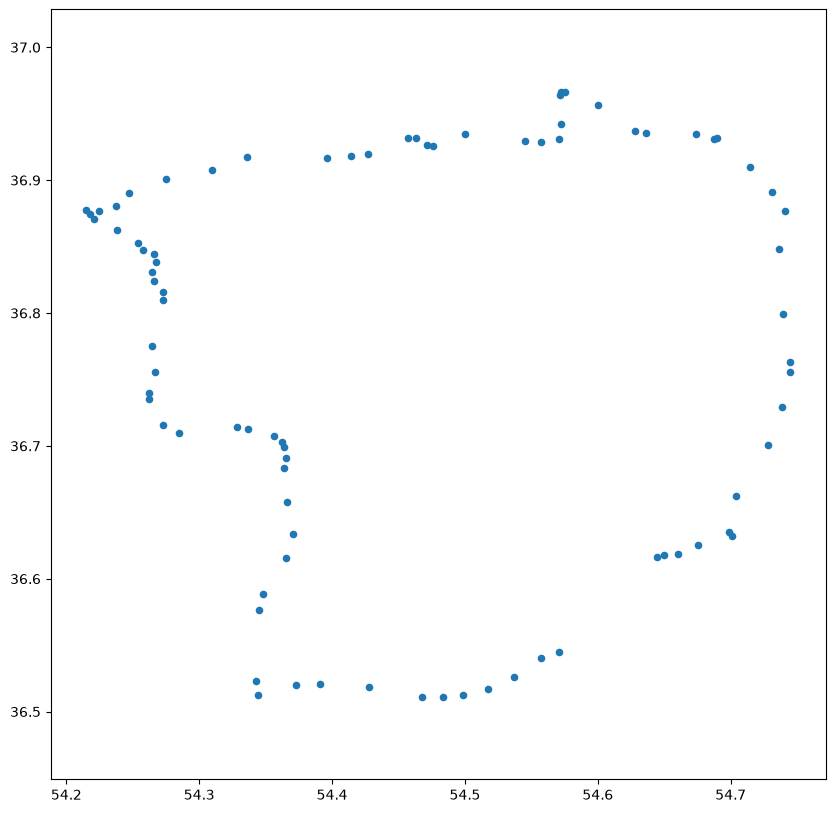

In [13]:
plt.figure(figsize=(10, 10))

plt.scatter(
    simplified_x,
    simplified_y,
    s=20
)

plt.axis("equal")

plt.show()

In [14]:
square = Polygon([
    Point(0, 0),
    Point(4, 0),
    Point(4, 3),
    Point(0, 3),
])

print(square.area())

12.0


In [15]:
print(gorgan.area())
print(simplified.area())

0.158930080375967
0.15886188479146313


In [16]:
square = Polygon([
    Point(0, 0),
    Point(4, 0),
    Point(4, 3),
    Point(0, 3),
])

print(square.perimeter())

14.0


In [17]:
bbox = square.bounding_box()

print(bbox)

BoundingBox(min_x=0.0, min_y=0.0, max_x=4.0, max_y=3.0)


In [18]:
print(square.centroid())

Point(x=2.0, y=1.5)


In [19]:
print(gorgan.area())

print(gorgan.perimeter())

print(gorgan.centroid())

print(gorgan.bounding_box())

0.158930080375967
1.7589055986052662
Point(x=54.50576194652009, y=36.75012022990377)
BoundingBox(min_x=54.214782900000046, min_y=36.51055590000004, max_x=54.74503510000005, max_y=36.96667720000005)


In [20]:
square = Polygon([
    Point(0, 0),
    Point(4, 0),
    Point(4, 3),
    Point(0, 3),
])

print(square.area())
print(square.centroid())

12.0
Point(x=2.0, y=1.5)


In [21]:
print(gorgan.area())

print(gorgan.centroid())

0.158930080375967
Point(x=54.50576194652009, y=36.75012022990377)


In [23]:
tehran = loader.load_city("تهران")
print(len(tehran))
print("Area:", tehran.area())
print("Centroid:", tehran.centroid())

2779
Area: 0.13800612593092865
Centroid: Point(x=51.40467583694512, y=35.72784492687947)


In [24]:
tehran_simple = tehran.simplify(0.001)
print("Original:", len(tehran))
print( "Simplified:", len(tehran_simple))

Original: 2779
Simplified: 211


In [26]:
original_area = tehran.area()
simplified_area = tehran_simple.area()

error = abs(original_area - simplified_area) / original_area * 100

print(f"Area error: {error:.2f}%")

Area error: 0.04%


In [27]:
from src.projection.transformer import UTMTransformer

transformer = UTMTransformer(40)

gorgan_center = gorgan.centroid()

meter_point = transformer.transform_point(
    gorgan_center
)

print(gorgan_center)

print(meter_point)

Point(x=54.50576194652009, y=36.75012022990377)
Point(x=277328.24685602786, y=4070053.9713480417)


In [28]:
from pyproj import Transformer

point = gorgan.centroid()

for zone in [38, 39, 40]:
    transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{32600 + zone}", always_xy=True)

    x, y = transformer.transform(point.x, point.y)

    print(f"Zone {zone}: X={x:.2f}, Y={y:.2f}")

Zone 38: X=1349650.57, Y=4109548.00
Zone 39: X=813002.60, Y=4072886.59
Zone 40: X=277328.25, Y=4070053.97


In [29]:
from src.projection.transformer import UTMTransformer

center = gorgan.centroid()

transformer = UTMTransformer.from_point(center)

print(transformer.zone)

40


In [30]:
center = gorgan.centroid()

print(center)
print(center.x)
print(center.y)

Point(x=54.50576194652009, y=36.75012022990377)
54.50576194652009
36.75012022990377


In [31]:
from src.projection.transformer import UTMTransformer

print(
    UTMTransformer.calculate_zone(center.x)
)

40


In [32]:
meter_point = transformer.transform_point(center)

print(center)
print(meter_point)

Point(x=54.50576194652009, y=36.75012022990377)
Point(x=277328.24685602786, y=4070053.9713480417)


In [33]:
gorgan_center = gorgan.centroid()
tehran_center = tehran.centroid()

print("Gorgan:")
print(gorgan_center)

print("Tehran:")
print(tehran_center)

Gorgan:
Point(x=54.50576194652009, y=36.75012022990377)
Tehran:
Point(x=51.40467583694512, y=35.72784492687947)


In [34]:
print(gorgan)
print(len(gorgan))
print(gorgan.centroid())

Polygon(vertices=326)
326
Point(x=54.50576194652009, y=36.75012022990377)


In [35]:
tehran_transformer = UTMTransformer.from_point(
    tehran.centroid()
)

print(tehran_transformer.zone)

39


In [36]:
center = gorgan.centroid()

transformer = UTMTransformer.from_point(center)

print(transformer.zone)

print(
    transformer.transform_point(center)
)

40
Point(x=277328.24685602786, y=4070053.9713480417)


In [37]:
transformer = UTMTransformer.from_point(gorgan.centroid())

gorgan_meter = gorgan.transform(transformer)

print(gorgan_meter)
print(gorgan_meter.vertices[:3])

Polygon(vertices=326)
(Point(x=251757.6298219907, y=4084901.347174672), Point(x=252616.4679518849, y=4084799.706494628), Point(x=253764.0884281915, y=4085185.6603195006))


In [38]:
print(gorgan.vertices[:3])
print(gorgan_meter.vertices[:3])

(Point(x=54.214782900000046, y=36.877461), Point(x=54.22444170000006, y=36.876771200000064), Point(x=54.23717870000007, y=36.88054630000005))
(Point(x=251757.6298219907, y=4084901.347174672), Point(x=252616.4679518849, y=4084799.706494628), Point(x=253764.0884281915, y=4085185.6603195006))


In [39]:
simplified_meter = gorgan_meter.simplify(100)

print("Original:", len(gorgan_meter))
print("Simplified:", len(simplified_meter))

Original: 326
Simplified: 90


In [40]:
original_area = gorgan_meter.area()
simplified_area = simplified_meter.area()

error = abs(original_area - simplified_area) / original_area * 100

print(f"Area error: {error:.4f}%")

Area error: 0.0274%


In [42]:
bbox = gorgan_meter.bounding_box()

print(bbox)

print(
    "Width:",
    bbox.width()
)

print(
    "Height:",
    bbox.height()
)

print(
    "Center:",
    bbox.center()
)

BoundingBox(min_x=251757.6298219907, min_y=4043539.23995397, max_x=298727.11862140015, max_y=4093923.27243775)
Width: 46969.488799409446
Height: 50384.032483779825
Center: Point(x=275242.3742216954, y=4068731.25619586)


In [43]:
bbox = gorgan_meter.bounding_box()

print(
    bbox.contains(
        gorgan_meter.centroid()
    )
)

True


In [44]:
from src.geometry.point import Point

outside = Point(
    100000,
    100000
)

print(
    bbox.contains(outside)
)

False
